- Tasks pending:
    - Keep all router nodes at one place in all notebooks
    - Finish adding/fixing comments and details in 4,5,6,7
    - Check issue in example `How many countries employees of Noventra Systems belong to?` why it's generating `no answer found` in first try even it is having 1 relevant doc, but in next retry it is generating actual answer. tagged as fully_sup in next retry as ans is coming fully from rel doc.


## Loading API Key

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

## Loading Necessary Libraries

In [2]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
import time

from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END

C:\Users\koyel\AppData\Local\Temp\ipykernel_4060\2711615123.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader
c:\Users\koyel\Downloads\python_practice\ai_ml_learning_journey\genai_and_agenticai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Initial Basic Steps
- Document Loading
- Chunking 
- Embedding
- Storing to VectorDB 

In [3]:
docs = DirectoryLoader(
    path = 'documents', 
    glob = '*.pdf',
    loader_cls = PyPDFLoader
).load()

- For chunking, values for parameters `chunk_size` and `chunk_overlap` is experimentally got here.

In [4]:
chunks = RecursiveCharacterTextSplitter(chunk_size = 600, chunk_overlap = 150).split_documents(docs)
embeddings = OpenAIEmbeddings(model = "text-embedding-3-large")
vector_store = FAISS.from_documents(chunks, embeddings)

## Creation of Retriever Object for Further Use

In [5]:
retriever = vector_store.as_retriever(search_kwargs = {'k': 4})

## LLM Object Creation

In [6]:
llm = ChatOpenAI(model = "gpt-4o-mini", temperature = 0)

## Define State
- `state` is a class which carries variables and their values at different steps of the workflow.
- Variables in `state` are modified as workflow proceeds.
- Variables:
    - `question`: user query
    - `need_retrieval`: basis on we route
    - `docs`: list of all retrieved docs
    - `relevant_docs`: list of relevant documents
    - `answer`: final answer which will be showed to user
- Can add description in schema itself.
- Here `relevant_docs` is newly added in `state` of the workflow.

In [7]:
class State(TypedDict):
    question: str

    # what we actually send to vector retriever
    retrieval_query: str
    rewrite_tries: int

    need_retrieval: bool
    
    docs: List[Document]
    relevant_docs: list[Document]

    context: str
    answer: str

    #post generation verification
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str]

    retries: int

    # usefulness check
    isuse: Literal["useful", "not_useful"]
    use_reason: str

## Define Output Schema and Prompt of Node to Decide Retrival
- This below part is to create node for should_retrieve
- Class `RetrieveDecicision` has only one variable `should_retrieve` which is a boolean variable as this output schema will be used for getting structured output from node `decide_retrieval`.

In [8]:
class RetrieveDecicision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description = "True if external documents are needed to answer reliably, else False"
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve = True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve = False for general explanations, definitions, or reasoning taht doesn't need sources.\n"
            "- If unsure. choose True."
        ),
        ("human", "Question: {question}")
    ]
)

- **`IMPORTANT`**: NO `.content` for structured output.

In [9]:
should_retrieve_llm = llm.with_structured_output(RetrieveDecicision)

def decide_retrieval(state: "State"):
    decision: RetrieveDecicision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question = state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}

## Define Prompt of Node to Generate Answer Via LLM
- As of this notebook below part will create answer for queries which are going to answer generating LLM directly without document retrieval.
- In later steps, post document retrieval and evaluation query will come to this node along with useful documents (if any) for answer generaion.

In [10]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specifics sources, say:\n"
            "I don't know based on my general knowledge."
        ),
        ("human", "{question}")
    ]
)

def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question = state["question"]
        )
    )
    return {
        "answer": out.content
    }

## Node for Retrieval
- This node will be used in case `decide_retrieval` decides that query requires to retrieve document. 

In [11]:
def retrieve(state: State):
    q = state.get("retrieval_query") or state["question"]
    return {"docs": retriever.invoke(q)}

In [12]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description = "true if the documment helps answer the question, else False."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You ar a judging document relavance.\n"
            "Return the JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        )
    ]
)

relevance_llm = llm.with_structured_output(RelevanceDecision)




def is_relevant(state: State):

    relevant_docs: List[Document] = []

    for doc in state["docs"]:
        decision: RelevanceDecision = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                question = state["question"],
                document = doc.page_content
            )
        )

        if decision.is_relevant:
            relevant_docs.append(doc)

    return {"relevant_docs": relevant_docs}

In [13]:
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n"
        )
    ]
)


def generate_from_context(state: State):
    # Stuff relevant docs into one block
    context = "\n\n---\n\n".join(
        [d.page_content for d in state.get("relevant_docs", [])]
    ).strip()
    if not context:
        return {"answer": "No answer found.", "context": ""}
    
    out = llm.invoke(
        rag_generation_prompt.format_messages(
            question = state["question"],
            context = context
        )
    )
    return {"answer": out.content, "context": context}

In [14]:
def no_relevant_docs(satte: State):
    return {"answer": "No answer found.", "context":""}

In [15]:
class IsSUPDecision(BaseModel):
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str] = Field(default_factory=list)

issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)



issup_llm = llm.with_structured_output(IsSUPDecision)

def is_sup(state: State):
    decision: IsSUPDecision = issup_llm.invoke(
        issup_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )
    return {"issup": decision.issup, "evidence": decision.evidence}

In [16]:
def accept_answer(state: State):
    return {}  # keep answer as-is

revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)



def revise_answer(state: State):
    out = llm.invoke(
        revise_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )
    return {
        "answer": out.content,
        "retries": state.get("retries", 0) + 1,  # ✅ increment
    }

In [17]:
class IsUSEDecision(BaseModel):
    isuse: Literal["useful", "not_useful"]
    reason: str = Field(..., description="Short reason in 1 line.")

isuse_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
            "Goal:\n"
            "- Decide if the answer actually addresses what the user asked.\n\n"
            "Return JSON with keys: isuse, reason.\n"
            "isuse must be one of: useful, not_useful.\n\n"
            "Rules:\n"
            "- useful: The answer directly answers the question or provides the requested specific info.\n"
            "- not_useful: The answer is generic, off-topic, or only gives related background without answering.\n"
            "- Do NOT use outside knowledge.\n"
            "- Do NOT re-check grounding (IsSUP already did that). Only check: 'Did we answer the question?'\n"
            "- Keep reason to 1 short line."
        ),
        (
            "human",
            "Question:\n{question}\n\nAnswer:\n{answer}"
        ),
    ]
)

isuse_llm = llm.with_structured_output(IsUSEDecision)

def is_use(state: State):
    decision: IsUSEDecision = isuse_llm.invoke(
        isuse_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
        )
    )
    return {"isuse": decision.isuse, "use_reason": decision.reason}

In [18]:
class RewriteDecision(BaseModel):
    retrieval_query: str = Field(
        ...,
        description="Rewritten query optimized for vector retrieval against internal company PDFs."
    )

rewrite_for_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user's QUESTION into a query optimized for vector retrieval over INTERNAL company PDFs.\n\n"
            "Rules:\n"
            "- Keep it short (6–16 words).\n"
            "- Preserve key entities (e.g., NexaAI, plan names).\n"
            "- Add 2–5 high-signal keywords that likely appear in policy/pricing docs.\n"
            "- Remove filler words.\n"
            "- Do NOT answer the question.\n"
            "- Output JSON with key: retrieval_query\n\n"
            "Examples:\n"
            "Q: 'Do NexaAI plans include a free trial?'\n"
            "-> {{'retrieval_query': 'NexaAI free trial duration trial period plans'}}\n\n"
            "Q: 'What is NexaAI refund policy?'\n"
            "-> {{'retrieval_query': 'NexaAI refund policy cancellation refund timeline charges'}}"
        ),
        (
            "human",
            "QUESTION:\n{question}\n\n"
            "Previous retrieval query:\n{retrieval_query}\n\n"
            "Answer (if any):\n{answer}"
        ),
    ]
)



rewrite_llm = llm.with_structured_output(RewriteDecision)

def rewrite_question(state: State):
    decision: RewriteDecision = rewrite_llm.invoke(
        rewrite_for_retrieval_prompt.format_messages(
            question=state["question"],
            retrieval_query=state.get("retrieval_query", ""),
            answer=state.get("answer", ""),
        )
    )

    return {
        "retrieval_query": decision.retrieval_query,
        "rewrite_tries": state.get("rewrite_tries", 0) + 1,
        # ✅ optional: reset these so next pass is clean
        "docs": [],
        "relevant_docs": [],
        "context": "",
    }

## Routing Node Function 
- `route_after_decide` will decide to retrieve documents or directly send query to answer generating LLM.

In [19]:
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

In [20]:
def route_after_relevance(state: State) -> Literal["generate_from_context", "no_relevant_docs"]:
    if state.get("relevant_docs") and len(state["relevant_docs"])>0:
        return "generate_from_context"
    return "no_relevant_docs"

In [21]:
MAX_RETRIES = 10

def route_after_issup(state: State) -> Literal["accept_answer", "revise_answer"]:
    # accept if fully supported
    if state.get("issup") == "fully_supported":
        return "accept_answer"

    # stop if we've already tried enough
    if state.get("retries", 0) >= MAX_RETRIES:
        return "accept_answer"   # or return a "give_up" node if you want

    # otherwise revise again
    return "revise_answer"

In [22]:
def route_after_isuse(state: State) -> Literal["END", "no_relevant_docs"]:
    if state.get("isuse") == "useful":
        return "END"
    return "no_relevant_docs"

## Define Graph
-  `retrieve` node is temporary end for retrieval path, as reasons discussed earlier.

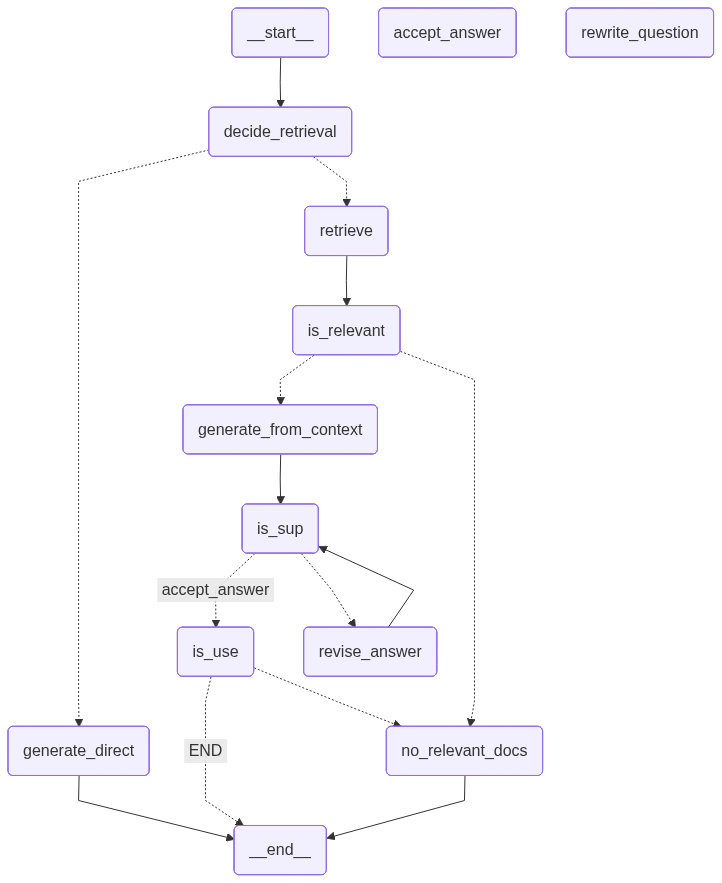

In [23]:
g = StateGraph(State)

g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)
g.add_node("is_relevant", is_relevant)
g.add_node("generate_from_context", generate_from_context)
g.add_node("no_relevant_docs", no_relevant_docs)
g.add_node("is_sup", is_sup)

g.add_node("accept_answer", accept_answer)
g.add_node("revise_answer", revise_answer)
g.add_node("is_use", is_use)
# rewrite question for better retrieval
g.add_node("rewrite_question", rewrite_question)


g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve"
    }
)


g.add_edge("generate_direct", END)

g.add_edge("retrieve", "is_relevant")

g.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {"generate_from_context": "generate_from_context", "no_relevant_docs": "no_relevant_docs"},
)

# If no answer found, end
g.add_edge("no_relevant_docs", END)

# Verify → (accept | revise) → verify loop
# --------------------
g.add_edge("generate_from_context", "is_sup")

g.add_conditional_edges(
    "is_sup",
    route_after_issup,  # fully_supported goes to IsUSE
    {
        "accept_answer": "is_use", 
        "revise_answer": "revise_answer"
    },
)

g.add_edge("revise_answer", "is_sup")  # 🔁 loop back to verify

# IsUSE routing
# --------------------
g.add_conditional_edges(
    "is_use",
    route_after_isuse,
    {
        "END": END,
        "no_relevant_docs": "no_relevant_docs",
    },
)


app = g.compile()
app

## Test on Questions
- Now we will see the decision on retrieval needed or not with two questions.

In [24]:
# -----------------------------
# Run the graph
# -----------------------------
initial_state = {
    "question": "Describe NexaAI’s company culture.",
    "retrieval_query": "What is the refund policy of NexaAI",  # ✅ important
    "rewrite_tries": 0,                                        # ✅ important
    "docs": [],
    "relevant_docs": [],
    "context": "",
    "answer": "",
    "issup": "",
    "evidence": [],
    "retries": 0,
    "isuse": "not_useful",
    "use_reason": "",
}


result = app.invoke(
    initial_state,
    config={"recursion_limit": 80},  # allow revise → verify loops
)

# -----------------------------
# Debug / inspection output (clean + complete)
# -----------------------------
print("\n===== RAG EXECUTION RESULT =====\n")

print("Question:", initial_state.get("question"))
print("Need Retrieval:", result.get("need_retrieval"))

# If you added these counters/fields in your State:
print("Rewrite tries (retrieval):", result.get("rewrite_tries", 0))
print("Support revise tries:", result.get("retries", 0))

print("\nRetrieval:")
print("  Total retrieved docs:", len(result.get("docs", []) or []))
print("  Relevant docs:", len(result.get("relevant_docs", []) or []))

# Optional: show sources/pages for relevant docs
relevant_docs = result.get("relevant_docs", []) or []
if relevant_docs:
    print("\nRelevant docs (source/page):")
    for i, d in enumerate(relevant_docs, 1):
        src = (d.metadata or {}).get("source", "unknown")
        page = (d.metadata or {}).get("page", None)
        title = (d.metadata or {}).get("title", "")
        extra = f", title={title}" if title else ""
        if page is not None:
            print(f"  {i}. source={src}, page={page}{extra}")
        else:
            print(f"  {i}. source={src}{extra}")

print("\nVerification (IsSUP):")
print("  issup:", result.get("issup"))
evidence = result.get("evidence", []) or []
if evidence:
    print("  evidence:")
    for e in evidence:
        print("   -", e)
else:
    print("  evidence: (none)")

print("\nUsefulness (IsUSE):")
print("  isuse:", result.get("isuse"))
print("  reason:", result.get("use_reason", ""))

print("\nFinal Answer:")
print(result.get("answer"))

print("\n===============================\n")


===== RAG EXECUTION RESULT =====

Question: Describe NexaAI’s company culture.
Need Retrieval: True
Rewrite tries (retrieval): 0
Support revise tries: 0

Retrieval:
  Total retrieved docs: 4
  Relevant docs: 0

Verification (IsSUP):
  issup: 
  evidence: (none)

Usefulness (IsUSE):
  isuse: not_useful
  reason: 

Final Answer:
No answer found.




In [ ]:
# how many employees does naxa ai have?
# describe nexaai's company culture
# do nexaai plans include a free trial? If yes, how may days?

In [ ]:
print("need_retrieval:", result.get("need_retrieval"))
print("#docs:", len(result.get("docs", [])))
print("#relevant_docs:", len(result.get("relevant_docs", [])))
print("issup:", result.get("issup"))
print("evidence:", result.get("evidence"))
print("answer:", result.get("answer"))

In [ ]:
print(result.get("retries"))

In [ ]:
for doc in result['relevant_docs']:
    print(doc.page_content)